# 📌 과제 문제

## 1. 과제 목표
- medical 데이터를 활용한 데이터 분석 리포트 작성  
- 데이터를 확인하여 통계적 특징을 도출하고, 시각화와 함께 문제 해결 방안 제시  

---

## 2. 제출 내용

### 1) 분석 코드
- Python을 활용한 데이터 분석 코드 작성  
- 변수별 통계 분석, 상관관계 분석, 시각화 포함  

### 2) 분석 리포트
- 데이터 설명 (데이터 수, 변수 설명 - 각 변수의 의미, 데이터 타입 등)  
- 분석 코드 설명  
- 분석 결과 및 결론 설명 (변수별 통계 분석 결과, 변수 간 상관관계 분석, 시각화 결과 포함)  
- 문제 해결 방법 제안 (분석 결과를 기반으로 한 노쇼 원인 파악 및 개선 방안 제시)  


In [27]:
import pandas as pd                     # pandas 라이브러리
import seaborn as sns                   # matplotlib 기반 색 테마 차트 추가하는 seaborn 라이브러리
import matplotlib.pyplot as plt         #
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


# 폰트 'Malgun Gothic' 사용
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


In [33]:
medical = pd.read_excel('data/medical.xls')
medical

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,29900000000000,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,No
1,559000000000000,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
2,4260000000000,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,No
3,868000000000,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,No
4,8840000000000,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
...,...,...,...,...,...,...,...,...,...
65530,749000000000000,5606399,F,2016-04-20T10:13:04Z,2016-05-19T00:00:00Z,69,SÃO CRISTÓVÃO,0,No
65531,81200000000000,5603951,F,2016-04-20T07:32:19Z,2016-05-06T00:00:00Z,35,SÃO CRISTÓVÃO,1,Yes
65532,37400000000000,5605835,M,2016-04-20T09:31:06Z,2016-05-13T00:00:00Z,65,SÃO CRISTÓVÃO,0,Yes
65533,45145119925,5606859,F,2016-04-20T10:47:37Z,2016-05-20T00:00:00Z,78,SÃO CRISTÓVÃO,0,No


# Medical 데이터 정보

In [34]:
# Medical 데이터 정보
medical.shape                   # Medical 데이터 행과 열의 개수
medical.columns                 # Medical 데이터 열 내용
medical.info()                  # Medical 데이터 정보
medical.describe()              # Medical 데이터 통계 요약 내용

print(medical['No-show'].value_counts())

''' Medical 데이터
    Medical 데이터 / 행 개수: 65535 열 개수: 9
    PatientID : 환자 ID                 / Ex) 29900000000000
    AppointmentID : 예약 ID             /     5642903
    Gender : 성별                       /     F(여자), M(남자)
    ScheduledDay : 예약 날짜            /      2016-04-29T18:38:08Z
    AppointmentDay : 진료 날짜          /      2016-04-29T00:00:00Z   
    Age : 나이                         /       0 ~ 115
    Neighbourhood : 병원 위치           /      JARDIM DA PENHA  
    SMS_received : 문자 메시지 수신 여부 /       0(수신 안함), 1(수신 함)
    No-show : 내원 여부                /       No(내원 함), Yes(내원 안함)       
    
 '''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PatientId       65535 non-null  int64 
 1   AppointmentID   65535 non-null  int64 
 2   Gender          65535 non-null  object
 3   ScheduledDay    65535 non-null  object
 4   AppointmentDay  65535 non-null  object
 5   Age             65535 non-null  int64 
 6   Neighbourhood   65535 non-null  object
 7   SMS_received    65535 non-null  int64 
 8   No-show         65535 non-null  object
dtypes: int64(4), object(5)
memory usage: 4.5+ MB
No-show
No     51614
Yes    13921
Name: count, dtype: int64


' Medical 데이터\n    Medical 데이터 / 행 개수: 65535 열 개수: 9\n    PatientID : 환자 ID                 / Ex) 29900000000000\n    AppointmentID : 예약 ID             /     5642903\n    Gender : 성별                       /     F(여자), M(남자)\n    ScheduledDay : 예약 날짜            /      2016-04-29T18:38:08Z\n    AppointmentDay : 진료 날짜          /      2016-04-29T00:00:00Z   \n    Age : 나이                         /       0 ~ 115\n    Neighbourhood : 병원 위치           /      JARDIM DA PENHA  \n    SMS_received : 문자 메시지 수신 여부 /       0(수신 안함), 1(수신 함)\n    No-show : 내원 여부                /       No(내원 함), Yes(내원 안함)       \n\n '

# 데이터 전처리 (결측치 및 이상치 제거)

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
SMS_received      0
No-show           0
dtype: int64
PatientId         False
AppointmentID     False
Gender            False
ScheduledDay      False
AppointmentDay    False
Age               False
Neighbourhood     False
SMS_received      False
No-show           False
dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
65530    False
65531    False
65532    False
65533    False
65534    False
Length: 65535, dtype: bool


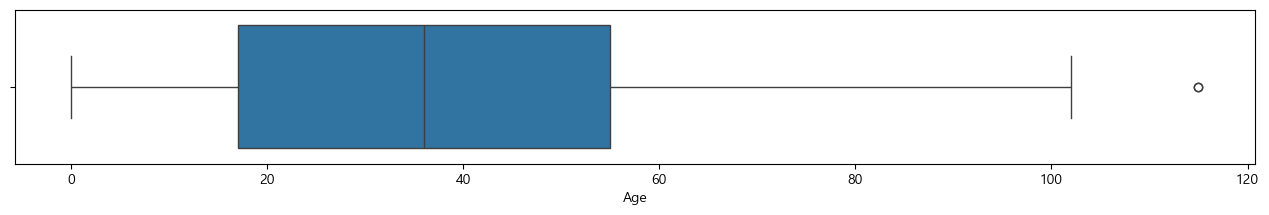

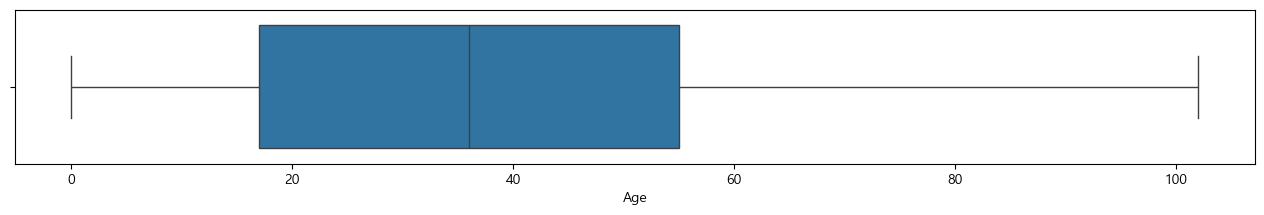

In [35]:
# 데이터 전처리
# 결측치 확인
print(medical.isnull().sum())        # Medical 데이터 결측치 확인
print(medical.isnull().any(axis=0))   # Medical 데이터 결측치 확인
print(medical.isnull().any(axis=1))   # Medical 데이터 결측치 확인
# 결측치 없음

# 이상치 확인 및 제거
medical.Age.unique()
medical = medical[medical.Age >= 0]   # 나이 이상치 제거
plt.figure(figsize=(16, 2))

# 상자그림으로 나이 시각화 및 이상치 제거
sns.boxplot(x=medical.Age)               # 나이 이상치 시각화
# => 나이 이상치 115세 
medical = medical[medical.Age <= 110]    # 나이 이상치 제거
plt.figure(figsize=(16, 2))
sns.boxplot(x=medical.Age)               # 나이 이상치 시각화

medical = medical[medical['Gender'].isin(['F', 'M'])]        # 성별 이상치 제거
medical = medical[medical['No-show'].isin(['No', 'Yes'])]    # 내원 여부 이상치 제거


# WaitingDay 추가

In [ ]:
# 데이터 처리를 위한 WaitngDay 열 추가
medical['ScheduledDay'] = pd.to_datetime(medical['ScheduledDay']).dt.date     # 예약 날짜 형식 변환
medical['AppointmentDay'] = pd.to_datetime(medical['AppointmentDay']).dt.date # 진료 날짜 형식 변환

# WaitingDay 생성
medical['WaitingDay'] = (medical['AppointmentDay'] - medical['ScheduledDay']).apply(lambda x: x.days)  # 예약 날짜와 진료 날짜의 차이 계산
print(medical[['ScheduledDay', 'AppointmentDay', 'WaitingDay']])

# WaitingDay: AppointmentDay(진료 날짜) - ScheduledDay(예약 날짜)

# 방문 당일 예약한 환자 중 노쇼 비율 확인
a = medical[medical['WaitingDay'].isin([0, -1])].shape[0]                                       # WaitingDay가 0, -1인 환자 수
b = medical[(medical['WaitingDay'].isin([0, -1])) & (medical['No-show'] == 'Yes')].shape[0]     # WaitingDay가 0, -1이고 No-show가 Yes인 환자 수
print(b/a)



      ScheduledDay AppointmentDay  WaitingDay
0       2016-04-29     2016-04-29           0
1       2016-04-29     2016-04-29           0
2       2016-04-29     2016-04-29           0
3       2016-04-29     2016-04-29           0
4       2016-04-29     2016-04-29           0
...            ...            ...         ...
65530   2016-04-20     2016-05-19          29
65531   2016-04-20     2016-05-06          16
65532   2016-04-20     2016-05-13          23
65533   2016-04-20     2016-05-20          30
65534   2016-04-20     2016-05-06          16

[65533 rows x 3 columns]
0.04960535976505139


# 재방문 환자 분석

In [22]:
# 재방문 환자의 확인

total_patient = medical.shape[0]                    # 전체 환자 수 65535      
print("재방문 환자의 확인:", total_patient, "\n")

# 고유 환자 수 (중복이 없는 PatientId 수)
unique_patient = medical['PatientId'].nunique()     # 고유 환자 수 5166
print("고유 환자 수:", unique_patient, "\n")

# medical 데이터 상위 10명의 환자 방문 횟수
medical_top10 = medical['PatientId'].value_counts().iloc[0:10]    # 상위 100명의 환자 방문 횟수
print("Medical 데이터 환자 상위 10명 방문 횟수:", medical_top10)


재방문 환자의 확인: 65533 

고유 환자 수: 5166 

Medical 데이터 환자 상위 10명 방문 횟수: PatientId
822000000000000    91
75800000000000     85
26900000000000     79
33500000000000     79
14500000000000     78
81900000000000     78
66800000000000     75
65400000000000     71
89200000000000     70
46800000000000     66
Name: count, dtype: int64


# 데이터 분석 시각화

# 0. 노쇼 데이터와 관련 있는 속성의 분석 시각화

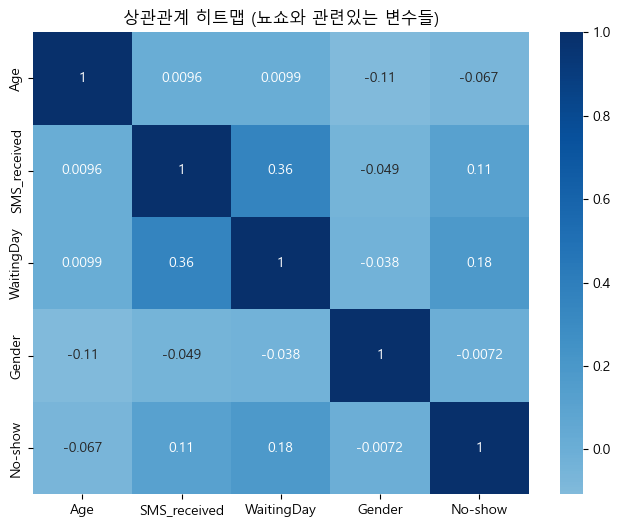

' Age & No-show = -0.067 \n    => Age와 No-show의 상관관계는 약함 Age가 높을수록 No-show가 낮아짐 상대적 나이가 높은 사람이 No-show가 적음\n\n    SMS_received & No-show = 0.11\n    => SMS와 No-show의 상관관계는 Age에 비해 강함\n\n    WaitingDay & No-show = 0.18\n    => WaitingDay는 다른 속성에 비해 강한 상관관계를 나타냄\n'

In [ ]:
medical['No-show'] = medical['No-show'].map({'No': 0, 'Yes': 1})                        # 데이터 heatmap 시각화를 위해 No-show 속성을 0과 1 로 변환
medical['Gender'] = medical['Gender'].map({'F': 0, 'M': 1})                         # Gender 속성을 0과 1로 변환
related_cols = ['Age', 'SMS_received', 'WaitingDay', 'Gender', 'No-show']                         # 노쇼 데이터과 관련 있는 속성
corr = medical[related_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', center=0)
plt.title('상관관계 히트맵 (뇨쇼와 관련있는 변수들)')
plt.show()

# 히트맵 결과 분석
''' Age & No-show = -0.067 
    => Age와 No-show의 상관관계는 약함 Age가 높을수록 No-show가 낮아짐 상대적 나이가 높은 사람이 No-show가 적음

    SMS_received & No-show = 0.11
    => SMS와 No-show의 상관관계는 Age에 비해 강함

    WaitingDay & No-show = 0.18
    => WaitingDay는 다른 속성에 비해 강한 상관관계를 나타냄

    Gender & No-show = -0.0072
    => 굉장히 낮은 상관관계를 나타냄 즉 Gender는 No-show와 관련이 없음
'''

# 1. Age와 No-show 데이터 비교
- 가설: Age(나이)가 많을수록 No-show가 적을 것

  AgeGroup   No-show
0     0-20  0.235102
1    20-60  0.219240
2   60-100  0.157278
AgeGroup
0-20      0.310942
20-60     0.554063
60-100    0.134995
Name: proportion, dtype: float64


C:\Users\a6742\AppData\Local\Temp\ipykernel_25688\1339253988.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_noshow1 = medical.groupby('AgeGroup')['No-show'].mean().reset_index()                   # 각 연령대 구간에서 No-show를 한 환자가 얼마나 차지하는지 비율 표시
C:\Users\a6742\AppData\Local\Temp\ipykernel_25688\1339253988.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_noshow1, x='AgeGroup', y='No-show', palette="coolwarm")                # 나이에 대한 노쇼 비교 1


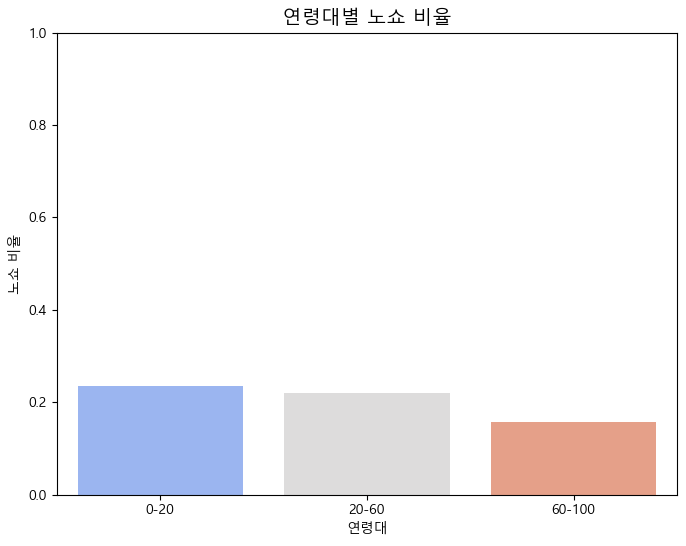

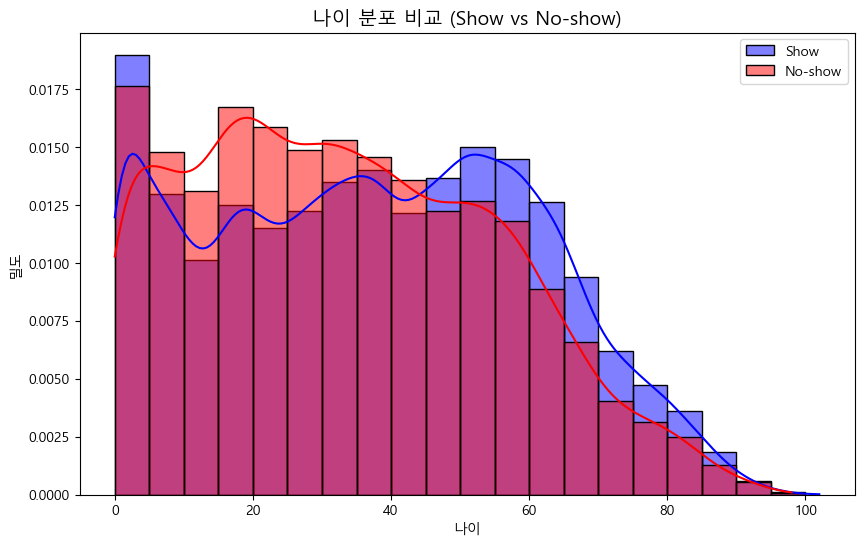

In [ ]:
# Age에 따른 No-show의 비율 비교
# 연령대를 0 ~ 20 / 20 ~ 60 / 60 ~ 100

bins = [0, 20, 60, 100]
labels = ['0-20', '20-60', '60-100']                # 연령대를 3개의 그룹으로 나눔
medical['AgeGroup'] = pd.cut(medical['Age'], bins=bins, labels=labels, right=False)         # 각 연령대에 알맞게 나이 그룹을 쪼갬
age_noshow1 = medical.groupby('AgeGroup')['No-show'].mean().reset_index()                   # 각 연령대 구간에서 No-show를 한 환자가 얼마나 차지하는지 비율 표시
print(age_noshow1)
''' 0 ~ 20 세 : 23%
    20 ~ 60세 : 21%
    60 ~ 100세: 15%
'''

no_show = medical[medical['No-show'] == 1]                                                  # No_show만 필터링
age_noshow2 = no_show['AgeGroup'].value_counts(normalize=True).sort_index()                 # 전체 No_show에 대한 연령대의 비율 
print(age_noshow2)
''' 0 ~ 20 세 : 31%
    20 ~ 60세 : 55%
    60 ~ 100세: 13%
    ㅡㅡㅡㅡㅡㅡㅡㅡㅡ
    총 합계: 100%
'''

plt.figure(figsize=(8,6))
sns.barplot(data=age_noshow1, x='AgeGroup', y='No-show', palette="coolwarm")                # 각 연령대에 대한 노쇼 비교
plt.title("연령대별 노쇼 비율", fontsize=14)
plt.xlabel("연령대")
plt.ylabel("노쇼 비율")
plt.ylim(0, 1)
plt.show()

''' 전체 연령대에 대해서 각 연령대 나이의 비율 밀도를 사용
    5 ~ 40 세: No-show가 높게 나타남 
    40 ~ 60세: show가 더 높게 나타남
    60 ~ 100세: 환자가 많이 줄어들지만 show가 더 높게 나타남
'''
plt.figure(figsize=(10, 6))
bins = range(0, 101, 5)
sns.histplot(data=medical[medical['No-show']==0]['Age'], bins=bins, color='blue', label='Show', kde=True, stat="density", alpha=0.5)
sns.histplot(data=medical[medical['No-show']==1]['Age'], bins=bins, color='red', label='No-show', kde=True, stat="density", alpha=0.5)
plt.title("나이 분포 비교", fontsize=14)
plt.xlabel("나이")
plt.ylabel("밀도")
plt.legend()
plt.show()


In [39]:
medical['WaitingDay'].max()

np.int64(176)

# 2. WaitingDay 와 No-show의 비교
- 가설: WaitingDay가 길수록 No-show가 많을 것

C:\Users\a6742\AppData\Local\Temp\ipykernel_25688\481680315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medical, x='WaitingDay', y='No-show', estimator=lambda x: sum(x)/len(x), palette='coolwarm')


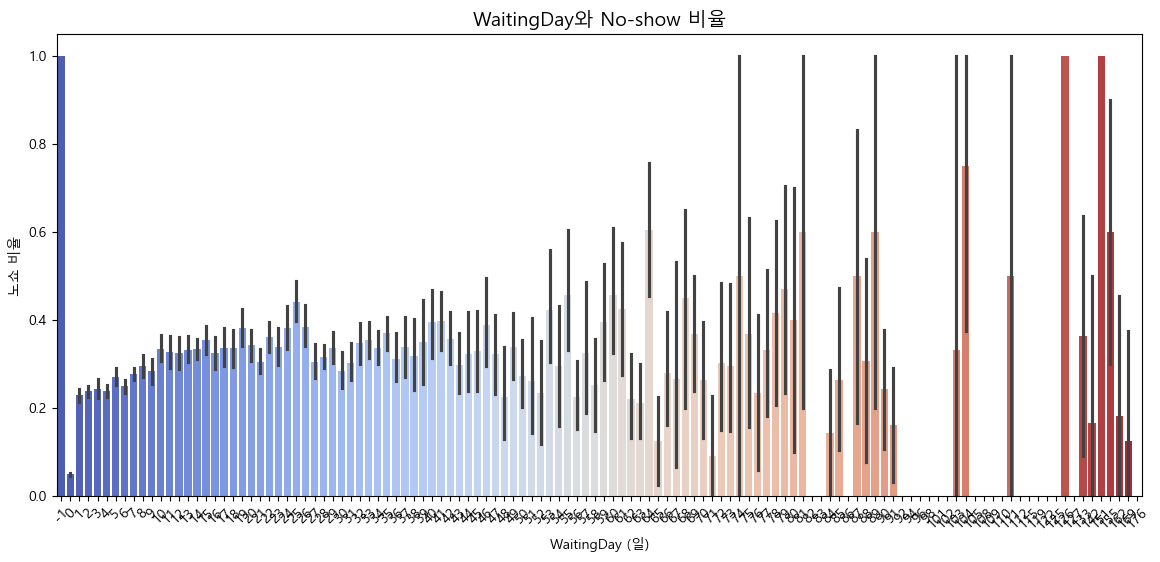

In [ ]:

# WaitingDay 구간화
bins = [-1, 0, 7, 14, 30, 176]                                                              # 176일이 최대 waitingDay
labels = ['0일', '1-7일', '8-14일', '15-30일', '31일+']
medical['WaitingGroup'] = pd.cut(medical['WaitingDay'], bins=bins, labels=labels)

# 그룹별 노쇼율 계산
wait_noshow = medical.groupby('WaitingGroup')['No-show'].mean().reset_index()

# 시각화
plt.figure(figsize=(8,6))
sns.barplot(data=wait_noshow, x='WaitingGroup', y='No-show', palette="coolwarm")
plt.title("대기일 구간별 No-show 비율", fontsize=14)
plt.xlabel("대기일 구간")
plt.ylabel("노쇼 비율")
plt.ylim(0, 1)
plt.show()



In [ ]:
sns.heatmap
related_cols = ['Age', 'SMS_received', 'WaitingDay', 'No-show']
corr = medical[related_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('상관관계 히트맵 (뇨쇼와 관련있는 변수들)')
plt.show()


# Age 관련
# 나이가 많을수록 잘 잊어서 노쇼를 자주 할 확률
# 나이가 어릴수록 책임감이 부족해 노쇼를 자주 할 확률

# WaitingDay 관련
# 방문 당일 예약한 환자에 대한 노쇼의 비교
# WaitindDay가 10일 이하인 데이터 비교
# WaitingDay가 50일 이상인 데이터 비교

# 재방문 환자 관련
# 재방문 환자 value_counts() 에 대한 노쇼의 비교 
# 지역간의 노쇼 상관관계 어떤 지역이 노쇼를 잘 당하는지

# SMS_received 관련
# sms 문자를 받지 않은 사람이 노쇼를 자주 할 것이다 => 상관관계를 확인할 것

